In [ ]:
Generative Adversial Networks:

    Generator vs Discriminator
    Adversarial Training Loop
    Why GANs are tricky (mode collapse, instability)
    Real-world uses: Image generation, super-resolution, text-to-image, style transfer

Simple Analogy

    Generator = a counterfeiter trying to make fake currency
    Discriminator = the police detecting fakes
    Both improve by competing

In [ ]:
#Minimax loss function

In [ ]:
# Remember the logic of "maximize correct classification for D, minimize detection for G".

In [ ]:
Training loop:

    Step 1: The Generator takes random noise as input and produces fake samples.
    Step 2: The Discriminator is shown both:
        Real samples from the dataset (label: real)
        Fake samples from the Generator (label: fake)

    Step 3:
        The Discriminator learns to correctly classify real vs fake.
        The Generator learns to fool the Discriminator into thinking its outputs are real.
    Repeat until the Generator produces highly realistic data.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
dataset = datasets.MNIST(root='/home/monsley/Downloads/online/GenAI/26072025/SOM/data', train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)


In [2]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 784),
            nn.Tanh()
        )
    def forward(self, z):
        img = self.model(z)
        return img.view(z.size(0), 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, img):
        return self.model(img.view(img.size(0), -1))


In [3]:
latent_dim = 100
generator = Generator(latent_dim)
discriminator = Discriminator()

criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)


Epoch [1/50] Loss D: 0.8784, Loss G: 0.9543


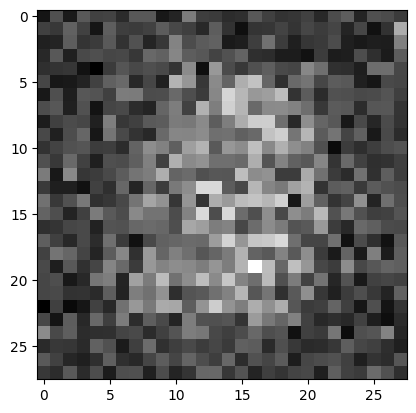

Epoch [2/50] Loss D: 1.2479, Loss G: 0.9082
Epoch [3/50] Loss D: 1.3263, Loss G: 0.7455
Epoch [4/50] Loss D: 1.1896, Loss G: 1.1709
Epoch [5/50] Loss D: 1.3834, Loss G: 0.7883
Epoch [6/50] Loss D: 1.2267, Loss G: 1.0114
Epoch [7/50] Loss D: 1.2522, Loss G: 0.9337
Epoch [8/50] Loss D: 1.5545, Loss G: 0.6265
Epoch [9/50] Loss D: 0.7241, Loss G: 1.4777
Epoch [10/50] Loss D: 1.2424, Loss G: 0.8542
Epoch [11/50] Loss D: 0.8917, Loss G: 1.2055


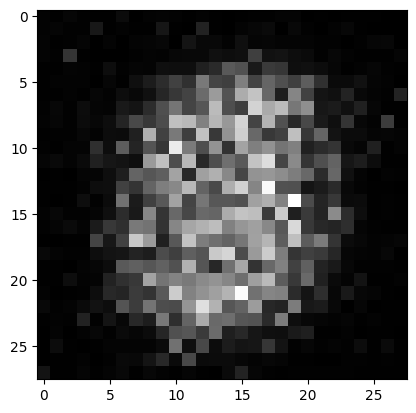

Epoch [12/50] Loss D: 1.4002, Loss G: 0.6954
Epoch [13/50] Loss D: 1.0901, Loss G: 1.0660
Epoch [14/50] Loss D: 0.6956, Loss G: 1.7001
Epoch [15/50] Loss D: 1.2828, Loss G: 1.1787
Epoch [16/50] Loss D: 0.8085, Loss G: 1.3232
Epoch [17/50] Loss D: 1.0746, Loss G: 1.2498
Epoch [18/50] Loss D: 1.4598, Loss G: 0.9900
Epoch [19/50] Loss D: 1.4774, Loss G: 0.9903
Epoch [20/50] Loss D: 1.0779, Loss G: 1.0669
Epoch [21/50] Loss D: 0.8217, Loss G: 1.1826


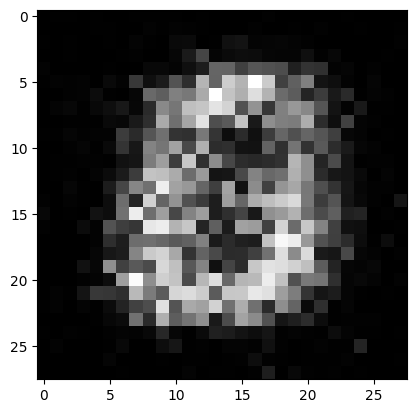

Epoch [22/50] Loss D: 0.5330, Loss G: 1.4648
Epoch [23/50] Loss D: 0.8646, Loss G: 1.4401
Epoch [24/50] Loss D: 0.6033, Loss G: 1.9658
Epoch [25/50] Loss D: 0.5598, Loss G: 2.0044
Epoch [26/50] Loss D: 0.7488, Loss G: 1.7781
Epoch [27/50] Loss D: 1.1288, Loss G: 1.1189
Epoch [28/50] Loss D: 0.8234, Loss G: 1.5836
Epoch [29/50] Loss D: 1.2943, Loss G: 1.3158
Epoch [30/50] Loss D: 1.5786, Loss G: 1.1528
Epoch [31/50] Loss D: 0.9522, Loss G: 1.5994


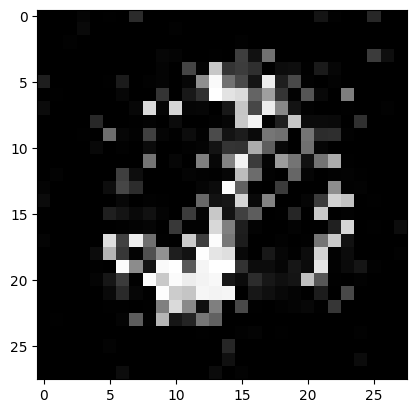

Epoch [32/50] Loss D: 0.8335, Loss G: 1.9234
Epoch [33/50] Loss D: 0.4815, Loss G: 2.9270
Epoch [34/50] Loss D: 0.6321, Loss G: 2.1922
Epoch [35/50] Loss D: 0.7112, Loss G: 1.7226
Epoch [36/50] Loss D: 0.6324, Loss G: 1.6078
Epoch [37/50] Loss D: 0.7786, Loss G: 1.5394
Epoch [38/50] Loss D: 0.9072, Loss G: 1.8602
Epoch [39/50] Loss D: 0.5498, Loss G: 2.4475
Epoch [40/50] Loss D: 0.4570, Loss G: 2.0958
Epoch [41/50] Loss D: 0.4946, Loss G: 2.9473


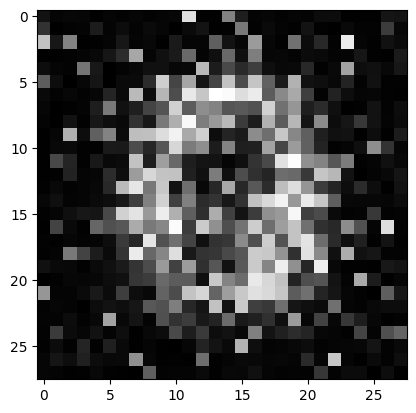

Epoch [42/50] Loss D: 0.6647, Loss G: 2.1693
Epoch [43/50] Loss D: 0.9743, Loss G: 2.3595
Epoch [44/50] Loss D: 0.5314, Loss G: 1.9349
Epoch [45/50] Loss D: 1.6919, Loss G: 1.0650
Epoch [46/50] Loss D: 0.8734, Loss G: 1.7277
Epoch [47/50] Loss D: 0.9823, Loss G: 2.1956
Epoch [48/50] Loss D: 0.7538, Loss G: 2.1754
Epoch [49/50] Loss D: 1.0405, Loss G: 2.0636
Epoch [50/50] Loss D: 0.4566, Loss G: 2.0491


In [4]:
epochs = 50
for epoch in range(epochs):
    for imgs, _ in dataloader:
        batch_size = imgs.size(0)

        # Real images
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # ----------------------
        # Train Discriminator
        # ----------------------
        optimizer_D.zero_grad()
        outputs = discriminator(imgs)
        loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, latent_dim)
        fake_imgs = generator(z)
        outputs = discriminator(fake_imgs.detach())
        loss_fake = criterion(outputs, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # ----------------------
        # Train Generator
        # ----------------------
        optimizer_G.zero_grad()
        z = torch.randn(batch_size, latent_dim)
        fake_imgs = generator(z)
        outputs = discriminator(fake_imgs)
        loss_G = criterion(outputs, real_labels)
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

    if epoch % 10 == 0:
        plt.imshow(fake_imgs[0].detach().view(28, 28), cmap='gray')
        plt.show()


In [ ]:
# Common problems:

Mode Collapse

What:
    The generator finds one (or a few) outputs that really fool the discriminator.
    Instead of exploring the whole data distribution, it keeps generating almost the same thing over and over.
    Example: If you’re training on MNIST, it might generate only a perfect-looking “3” and ignore all other digits.

Why:
    The generator updates to exploit a current weakness in the discriminator.
    Once the discriminator catches up, the generator might jump to a different single mode.
    The game becomes a cat-and-mouse loop instead of a balanced learning of the whole distribution.

How:
    Use minibatch discrimination so D can detect lack of diversity.
    Try label smoothing (e.g., use 0.9 for real labels instead of 1.0).
    Use feature matching loss (match intermediate D activations instead of only D’s final output).
    Train D a bit more before G early in training, to avoid G exploiting random weaknesses.


The Ice Cream Shop Analogy
    Imagine an ice cream shop that offers 10 flavors (real dataset).
    The generator’s job is to “invent” fake scoops.
    At first, it tries many flavors.
    Suddenly it discovers that chocolate always fools the discriminator.
    It stops producing vanilla, strawberry, mint…
    Now, all “fake” ice creams are chocolate → mode collapse.



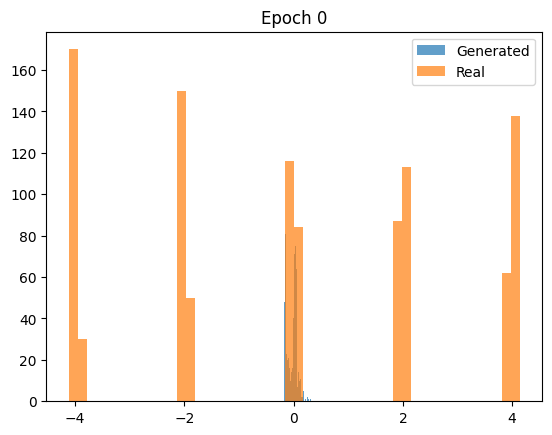

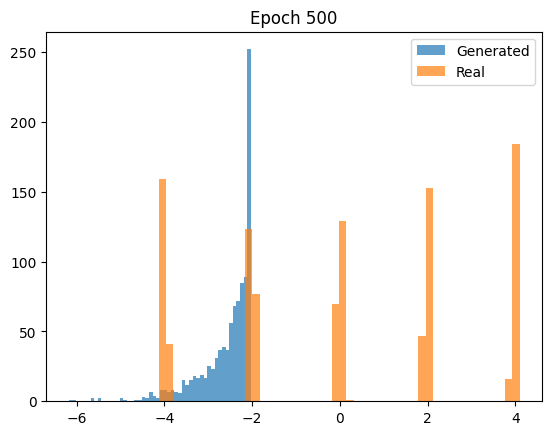

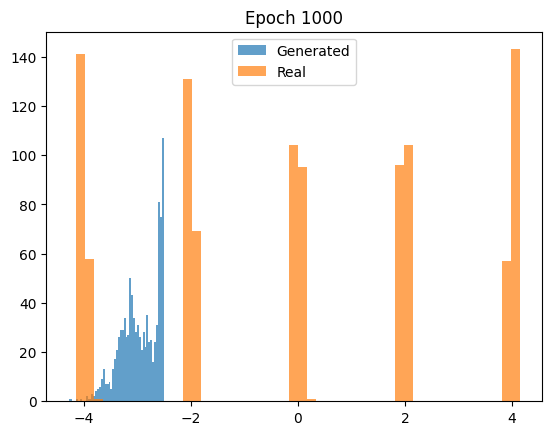

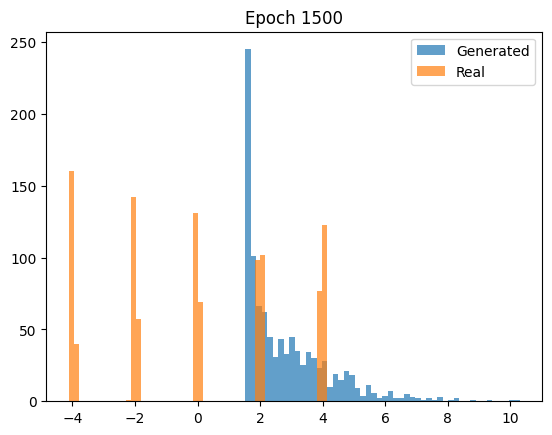

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Create real data: mixture of Gaussians
def real_data(n=512):
    centers = torch.tensor([-4, -2, 0, 2, 4], dtype=torch.float)
    data = torch.cat([torch.randn(n//5, 1) * 0.05 + c for c in centers])
    return data

# Generator & Discriminator (small MLPs)
class Gen(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, z):
        return self.net(z)

class Disc(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 32), nn.ReLU(), nn.Linear(32, 1), nn.Sigmoid())
    def forward(self, x):
        return self.net(x)

G, D = Gen(), Disc()
opt_G = optim.Adam(G.parameters(), lr=0.001)
opt_D = optim.Adam(D.parameters(), lr=0.001)
loss_fn = nn.BCELoss()

# Train GAN but bias towards collapse
for epoch in range(2000):
    # Train Discriminator
    real = real_data(64)
    batch_size = real.size(0)   
    z = torch.randn(batch_size, 1)  
    fake = G(z).detach()

    loss_D = loss_fn(D(real), torch.ones(batch_size, 1)) \
            + loss_fn(D(fake), torch.zeros(batch_size, 1))

    opt_D.zero_grad(); loss_D.backward(); opt_D.step()
    
    # Train Generator (intentionally fewer updates to mimic collapse)
    z = torch.randn(batch_size, 1)
    fake = G(z)
    loss_G = loss_fn(D(fake), torch.ones(batch_size, 1))
    opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    if epoch % 500 == 0:
        plt.hist(G(torch.randn(1000, 1)).detach().numpy(), bins=50, alpha=0.7, label='Generated')
        plt.hist(real_data(1000).numpy(), bins=50, alpha=0.7, label='Real')
        plt.legend(); plt.title(f"Epoch {epoch}"); plt.show()



In [ ]:
Unstable Training

What?:
    GAN loss curves often do not converge.
    Sometimes the generator produces nonsense even after many epochs, or D becomes too strong and G fails to learn.

Why?:
    The GAN objective is a minimax game — not a simple loss minimization.
    If D learns too fast, G gets no useful gradient.
    If G learns too fast, D gets confused and can’t recover.

Signs?:
    D loss goes to near 0 and G loss skyrockets → D too strong.
    G loss very low but outputs are bad → G is fooling D with “garbage” patterns.

How?:
    Use Wasserstein GAN (WGAN) with gradient penalty — it gives more stable, meaningful loss values.
    Add noise to real and fake inputs to prevent overconfidence in D.
    Use spectral normalization in D for controlled capacity.

In [ ]:
Learning Rate Balance

What it is:
    Even small differences in learning rate between G and D can cause one to overpower the other.

Why it matters:
    GANs need both players to improve at roughly the same pace.
    Too high LR for D → D crushes G quickly, G gets no gradient.
    Too high LR for G → G may oscillate wildly and not learn stable patterns.

Practical tips:
    Often use the same LR for both (e.g., 0.0002 with Adam, betas=(0.5, 0.999) for DCGAN).
    If mode collapse or D domination appears, try lowering D’s LR slightly.
    Keep batch sizes moderate — too large batch + high LR can destabilize updates.

In [ ]:
# Use cases

1. Computer Vision

    Image-to-Image Translation
        Pix2Pix: Converting satellite images → maps, edges → photos.
        CycleGAN: Translating between domains without paired data (e.g., summer ↔ winter scenery).
    Super-Resolution
        SRGAN: Upscaling low-resolution images to high-res for medical imaging, security cameras.
    Image Inpainting / Completion
        Filling missing or corrupted image parts (e.g., Photoshop “content-aware fill”).
    Style Transfer
        Applying Van Gogh or Picasso style to photos.

2. Healthcare & Life Sciences

    Medical Image Synthesis
        Generating MRI/CT images for rare cases to augment datasets.
        Modality translation: CT → MRI without re-scanning.
    Drug Discovery
        GANs generating molecular structures with desired properties (MolGAN).

    Data Anonymization
        Creating synthetic but statistically realistic patient data.

3. Video & Animation

    Deepfake Video Generation
        Face swapping, lip-syncing for entertainment or education.
        (Ethical considerations required here.)
    Frame Interpolation
        Smoother slow-motion by generating in-between frames.
    Video Prediction
        Predicting the next frames in a sequence (useful in robotics).

4. Audio & Speech

    Speech Synthesis
        WaveGAN, MelGAN: Generating realistic speech or environmental sounds.
    Voice Conversion
        Converting one speaker’s voice to another while preserving words.
    Music Generation
        Composing music in a specific style (JazzGAN, MuseGAN).

5. Text & Multimodal

    Text-to-Image Synthesis
        AttnGAN, DALL·E-style GANs: Generate images from text descriptions.
    Scene Graph to Image
        Generating images from structured descriptions.
    Data Augmentation for NLP
        Synthetic handwriting generation for OCR training.

6. Security & Anomaly Detection

    GANs for Cybersecurity
        Generate realistic network traffic to train intrusion detection systems.
    Anomaly Detection
        Train GAN on “normal” data; high reconstruction error signals anomalies.

7. Industrial & Scientific Applications

    Manufacturing Defect Detection
        GAN learns normal product appearance, flags deviations.
    Physics Simulations
        Approximate complex simulations in fluid dynamics, particle physics.
    Satellite & Remote Sensing
        Cloud removal, super-resolution for land mapping.

In [ ]:
Types of GANs

    DCGAN → Deep convolutional GAN for images.
    Conditional GAN (cGAN) → GAN with labels to control generation.
    CycleGAN → Translates images from one domain to another (e.g., horses ↔ zebras).
    StyleGAN → High-quality, realistic face generation.
    Pix2Pix → Image-to-image translation.

# DCGAN (Deep Convolutional GAN)

Use: Generate images (e.g., MNIST digits, faces).
Architecture: CNN layers instead of fully connected.

Key Idea:
    Generator uses ConvTranspose2D for upsampling.
    Discriminator uses Conv2D for downsampling.

100%|███████████████████████████████████████| 9.91M/9.91M [00:10<00:00, 940kB/s]
100%|██████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 94.3kB/s]
100%|███████████████████████████████████████| 1.65M/1.65M [00:03<00:00, 447kB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 4.78MB/s]


Epoch 1/5 | Loss D: 0.7990 | Loss G: 0.9548
Epoch 2/5 | Loss D: 0.7270 | Loss G: 1.3081
Epoch 3/5 | Loss D: 0.5762 | Loss G: 1.6454
Epoch 4/5 | Loss D: 0.9054 | Loss G: 1.2268
Epoch 5/5 | Loss D: 0.4717 | Loss G: 1.7361


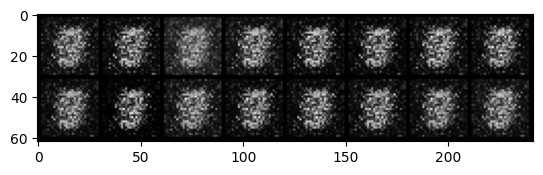

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
dataset = torchvision.datasets.MNIST(root='./data', download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

# Generator
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_dim=28*28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, img_dim),
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self, img_dim=28*28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# Initialize
device = 'cuda' if torch.cuda.is_available() else 'cpu'
z_dim = 100
G = Generator(z_dim).to(device)
D = Discriminator().to(device)
lr = 0.0002

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=lr)
opt_D = optim.Adam(D.parameters(), lr=lr)

# Training
epochs = 5
for epoch in range(epochs):
    for real, _ in dataloader:
        real = real.view(-1, 28*28).to(device)
        batch_size = real.size(0)
        noise = torch.randn(batch_size, z_dim).to(device)

        # Train Discriminator
        loss_D = criterion(D(real), torch.ones(batch_size, 1).to(device)) + \
                 criterion(D(G(noise).detach()), torch.zeros(batch_size, 1).to(device))
        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        loss_G = criterion(D(G(noise)), torch.ones(batch_size, 1).to(device))
        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch+1}/{epochs} | Loss D: {loss_D:.4f} | Loss G: {loss_G:.4f}")

# Generate images
noise = torch.randn(16, z_dim).to(device)
fake_images = G(noise).view(-1, 1, 28, 28)
plt.imshow(make_grid(fake_images, normalize=True).permute(1, 2, 0).cpu())
plt.show()


In [ ]:
3. Conditional GAN (cGAN)

Use: Generate images conditioned on labels.
Example: Generate MNIST digit “7” only.
    Input = noise + label embedding.

4. CycleGAN # Seperate notebook
# Repository - https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix?tab=readme-ov-file
Use: Unpaired image-to-image translation.
Example: Horse ↔ Zebra without paired datasets.

    Two Generators: G:X→Y, F:Y→X
    Cycle Consistency Loss ensures F(G(x))≈x.

5. StyleGAN
Use: Ultra-realistic face generation.
    Progressive growing of GANs.
    Style mixing and control over image features.
    We can run a pretrained StyleGAN2-ADA on Google Colab.

6. Pix2Pix
#Repository - https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix?tab=readme-ov-file
Use: Paired image-to-image translation.
Example: Sketch → Photo, Map → Satellite.

   Limitations-  Works with paired datasets.

Epoch 1/10  |  D loss: 0.5349  |  G loss: 1.2785


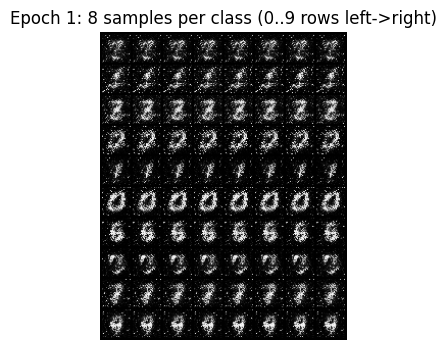

Epoch 2/10  |  D loss: 0.4121  |  G loss: 1.8351


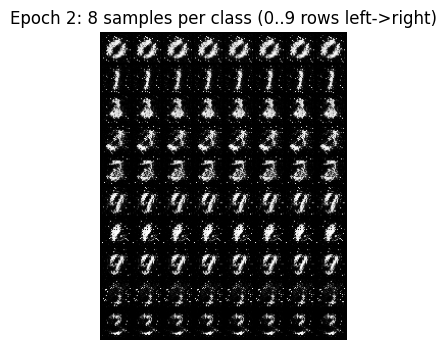

Epoch 3/10  |  D loss: 0.3520  |  G loss: 2.1717


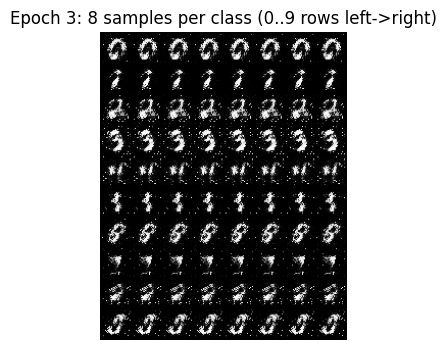

Epoch 4/10  |  D loss: 0.3281  |  G loss: 2.3676


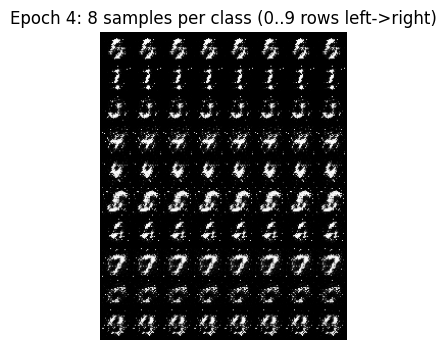

Epoch 5/10  |  D loss: 0.3094  |  G loss: 2.4385


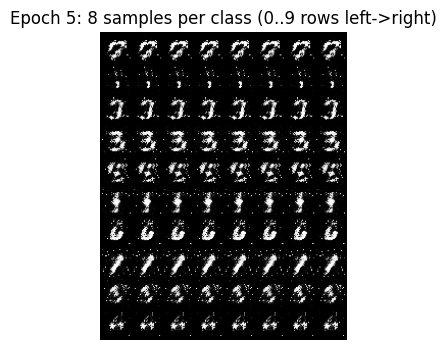

Epoch 6/10  |  D loss: 0.3040  |  G loss: 2.5531


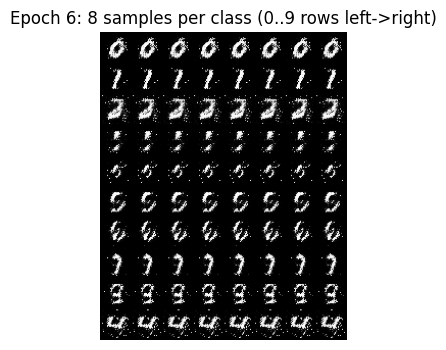

Epoch 7/10  |  D loss: 0.2995  |  G loss: 2.4792


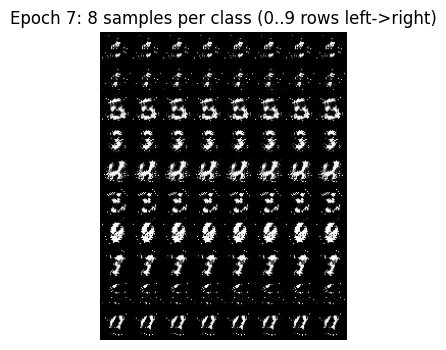

Epoch 8/10  |  D loss: 0.2830  |  G loss: 2.6744


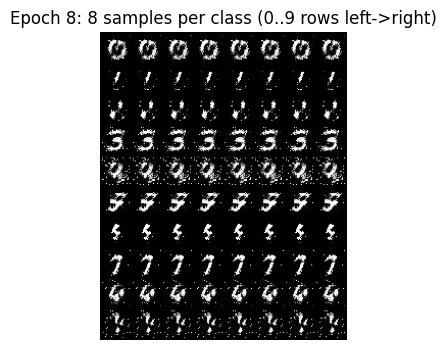

Epoch 9/10  |  D loss: 0.2914  |  G loss: 2.7501


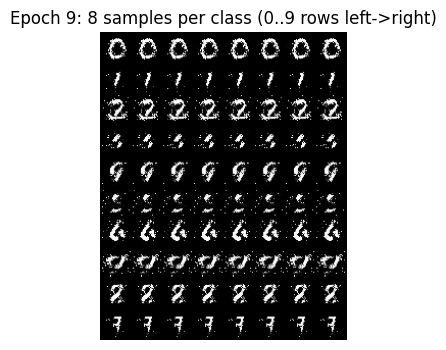

Epoch 10/10  |  D loss: 0.2749  |  G loss: 2.7606


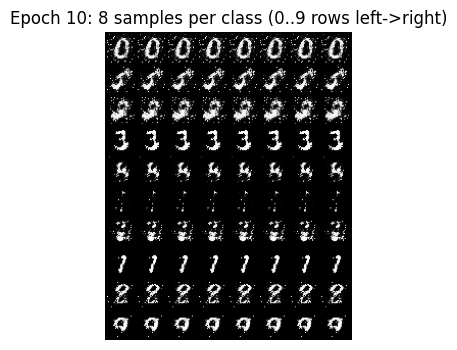

In [22]:
# Conditional GAN


import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# --- Config ---
device = "cuda" if torch.cuda.is_available() else "cpu"
z_dim = 100
label_emb_dim = 50
batch_size = 128
lr = 2e-4
epochs = 10           # increase to 30-50 for better quality
beta1, beta2 = 0.5, 0.999

# --- Data ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # map [0,1] to [-1,1]
])
dataset = datasets.MNIST(root="/home/monsley/Downloads/online/GenAI/26072025/SOM/data", train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# --- Models ---
class Generator(nn.Module):
    def __init__(self, z_dim, label_emb_dim, img_dim=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(10, label_emb_dim)
        input_dim = z_dim + label_emb_dim
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, img_dim),
            nn.Tanh()   # outputs in [-1,1]
        )
    def forward(self, z, labels):
        # z: (B, z_dim), labels: (B,)
        le = self.label_emb(labels)              # (B, label_emb_dim)
        x = torch.cat([z, le], dim=1)            # (B, z+label_emb)
        img = self.net(x)
        return img.view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self, label_emb_dim, img_dim=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(10, label_emb_dim)
        input_dim = img_dim + label_emb_dim
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, img, labels):
        # img: (B,1,28,28), labels: (B,)
        flat = img.view(img.size(0), -1)
        le = self.label_emb(labels)
        x = torch.cat([flat, le], dim=1)
        out = self.net(x)
        return out

G = Generator(z_dim, label_emb_dim).to(device)
D = Discriminator(label_emb_dim).to(device)

# --- Loss & Optimizers ---
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))

# --- Fixed noise for visualization: create one fixed vector per class ---
n_samples_per_class = 8
fixed_z = torch.randn(10 * n_samples_per_class, z_dim).to(device)
fixed_labels = torch.tensor([i for i in range(10) for _ in range(n_samples_per_class)], dtype=torch.long).to(device)

# --- Training loop ---
for epoch in range(1, epochs+1):
    G.train(); D.train()
    running_d_loss = 0.0
    running_g_loss = 0.0
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        bsize = imgs.size(0)

        # Real / Fake labels
        real = torch.ones(bsize, 1, device=device)
        fake = torch.zeros(bsize, 1, device=device)

        ## ---- Train Discriminator ----
        opt_D.zero_grad()
        # Real loss
        out_real = D(imgs, labels)
        loss_real = criterion(out_real, real)

        # Fake loss
        z = torch.randn(bsize, z_dim, device=device)
        gen_labels = torch.randint(0, 10, (bsize,), device=device)  # sample labels for fake images
        fake_imgs = G(z, gen_labels).detach()   # detach so G not updated here
        out_fake = D(fake_imgs, gen_labels)
        loss_fake = criterion(out_fake, fake)

        d_loss = (loss_real + loss_fake) * 0.5
        d_loss.backward()
        opt_D.step()

        ## ---- Train Generator ----
        opt_G.zero_grad()
        z = torch.randn(bsize, z_dim, device=device)
        gen_labels = torch.randint(0, 10, (bsize,), device=device)
        gen_imgs = G(z, gen_labels)
        # want discriminator to predict them as real
        g_loss = criterion(D(gen_imgs, gen_labels), real)
        g_loss.backward()
        opt_G.step()

        running_d_loss += d_loss.item()
        running_g_loss += g_loss.item()

    # --- Logging + Visualize fixed samples ---
    avg_d = running_d_loss / len(loader)
    avg_g = running_g_loss / len(loader)
    print(f"Epoch {epoch}/{epochs}  |  D loss: {avg_d:.4f}  |  G loss: {avg_g:.4f}")

    # Visualize one row per digit using fixed noise/labels
    G.eval()
    with torch.no_grad():
        gen = G(fixed_z, fixed_labels).cpu()
    # make a grid: group by class for nicer layout
    grid = make_grid(gen, nrow=n_samples_per_class, normalize=True, value_range=(-1,1))
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(grid, (1, 2, 0)), cmap='gray')
    plt.axis('off')
    plt.title(f"Epoch {epoch}: {n_samples_per_class} samples per class (0..9 rows left->right)")
    plt.show()


In [23]:
# Another example

%matplotlib inline
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torch import autograd
from torch.autograd import Variable
from torchvision.utils import make_grid
import matplotlib.pyplot as plt


In [24]:
class FashionMNIST(Dataset):
    def __init__(self, transform=None):
        self.transform = transform
        fashion_df = pd.read_csv('fashion-mnist_train.csv')
        self.labels = fashion_df.label.values
        self.images = fashion_df.iloc[:, 1:].values.astype('uint8').reshape(-1, 28, 28)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        label = self.labels[idx]
        img = Image.fromarray(self.images[idx])
        
        if self.transform:
            img = self.transform(img)

        return img, label

In [25]:
dataset = FashionMNIST()
dataset[0][0]

In [51]:
# transform = transforms.Compose([
#         transforms.ToTensor(),
#         transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
# ])


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Single value tuple for 1 channel
])


dataset = FashionMNIST(transform=transform)
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)


In [52]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.label_emb = nn.Embedding(10, 10)
        
        self.model = nn.Sequential(
            nn.Linear(794, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x, labels):
        x = x.view(x.size(0), 784)
        c = self.label_emb(labels)
        x = torch.cat([x, c], 1)
        out = self.model(x)
        return out.squeeze()

In [53]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.label_emb = nn.Embedding(10, 10)
        
        self.model = nn.Sequential(
            nn.Linear(110, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh()
        )
    
    def forward(self, z, labels):
        z = z.view(z.size(0), 100)
        c = self.label_emb(labels)
        x = torch.cat([z, c], 1)
        out = self.model(x)
        return out.view(x.size(0), 28, 28)


In [54]:
generator = Generator().cuda()
discriminator = Discriminator().cuda()

In [55]:
criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)
g_optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4)

In [59]:
def generator_train_step(batch_size, discriminator, generator, g_optimizer, criterion):
    g_optimizer.zero_grad()
    z = torch.randn(batch_size, 100, device='cuda')
    fake_labels = torch.randint(0, 10, (batch_size,), dtype=torch.long, device='cuda')
    fake_images = generator(z, fake_labels)
    validity = discriminator(fake_images, fake_labels)
    g_loss = criterion(validity, torch.ones(batch_size, device='cuda'))
    g_loss.backward()
    g_optimizer.step()
    return g_loss.item()

def discriminator_train_step(batch_size, discriminator, generator, d_optimizer, criterion, real_images, labels):
    d_optimizer.zero_grad()

    real_validity = discriminator(real_images, labels)
    real_loss = criterion(real_validity, torch.ones(batch_size, device='cuda'))
    
    z = torch.randn(batch_size, 100, device='cuda')
    fake_labels = torch.randint(0, 10, (batch_size,), dtype=torch.long, device='cuda')
    fake_images = generator(z, fake_labels)
    fake_validity = discriminator(fake_images, fake_labels)
    fake_loss = criterion(fake_validity, torch.zeros(batch_size, device='cuda'))
    
    d_loss = real_loss + fake_loss
    d_loss.backward()
    d_optimizer.step()
    return d_loss.item()


Starting epoch 0...
g_loss: 3.755326271057129, d_loss: 0.3947778344154358


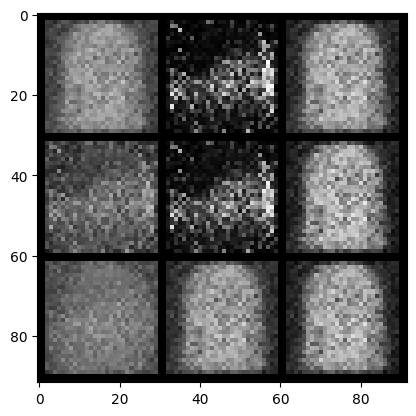

Starting epoch 1...
g_loss: 4.213313102722168, d_loss: 0.1966363489627838


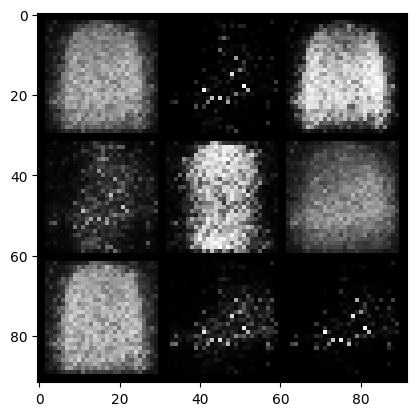

Starting epoch 2...
g_loss: 3.8011634349823, d_loss: 0.2716943919658661


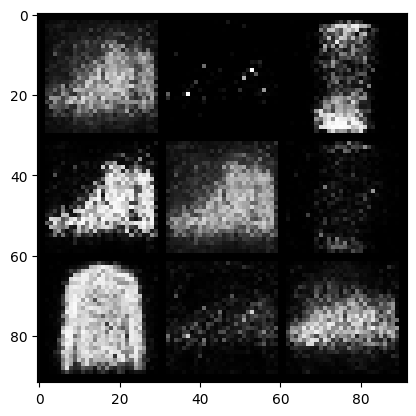

Starting epoch 3...
g_loss: 3.2234342098236084, d_loss: 0.6110891103744507


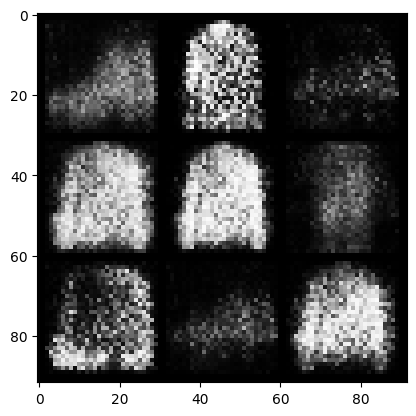

Starting epoch 4...
g_loss: 2.9311037063598633, d_loss: 0.7532153129577637


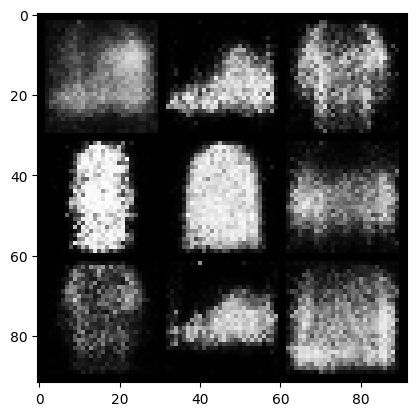

Starting epoch 5...
g_loss: 2.211000919342041, d_loss: 0.597725510597229


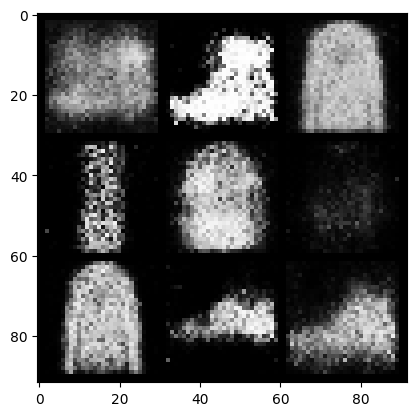

Starting epoch 6...
g_loss: 2.3040103912353516, d_loss: 0.6385285258293152


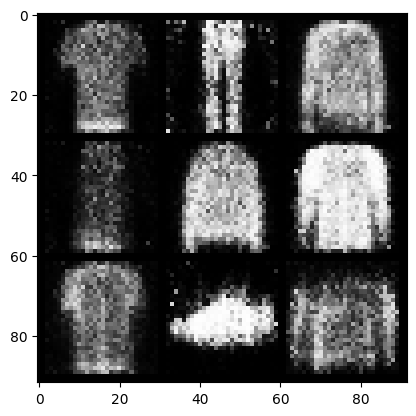

Starting epoch 7...
g_loss: 2.233940839767456, d_loss: 0.5852319002151489


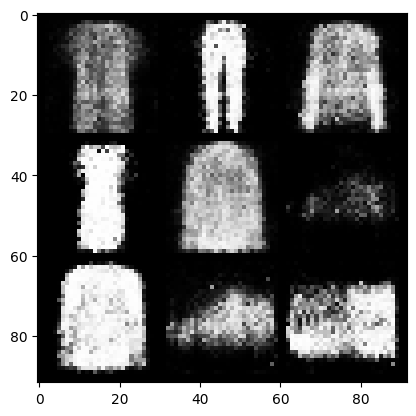

Starting epoch 8...
g_loss: 2.2506980895996094, d_loss: 0.5468449592590332


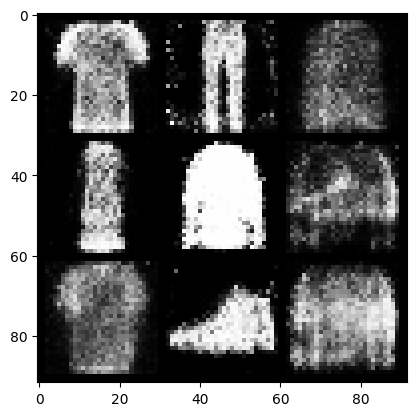

Starting epoch 9...
g_loss: 1.7825876474380493, d_loss: 0.8229859471321106


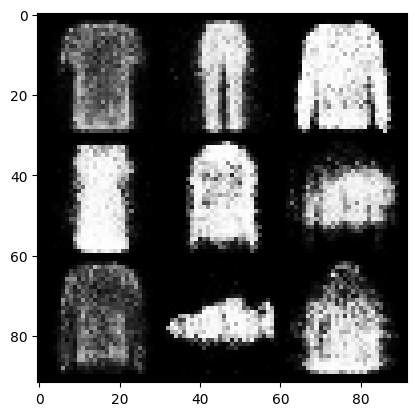

Starting epoch 10...
g_loss: 1.9006102085113525, d_loss: 1.1955835819244385


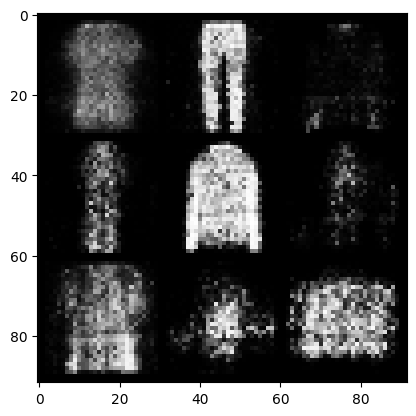

Starting epoch 11...
g_loss: 2.0678958892822266, d_loss: 0.5853966474533081


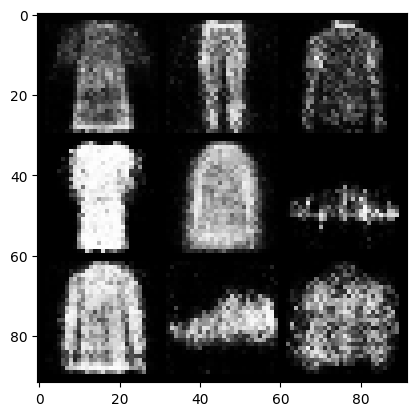

Starting epoch 12...
g_loss: 1.7972285747528076, d_loss: 0.9592512249946594


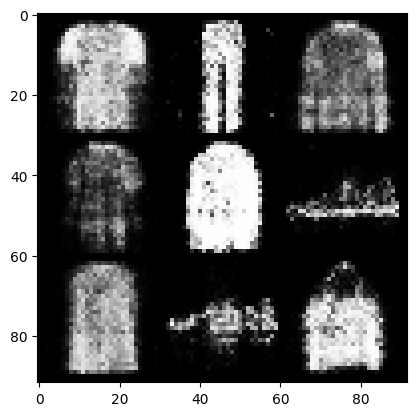

Starting epoch 13...
g_loss: 1.6287380456924438, d_loss: 0.9258996844291687


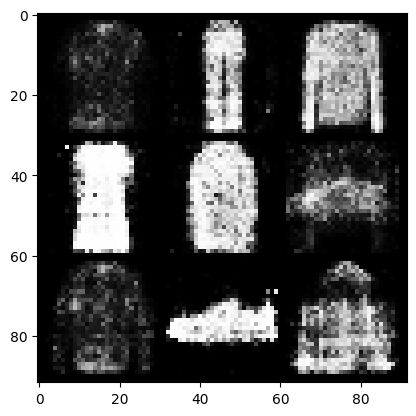

Starting epoch 14...
g_loss: 1.3816299438476562, d_loss: 0.8524950742721558


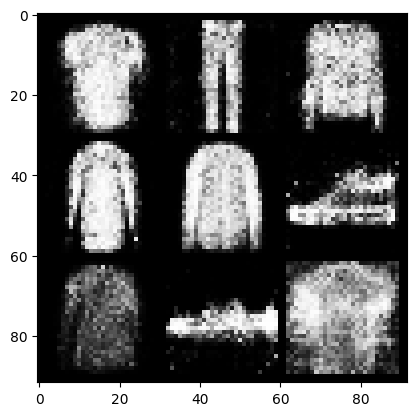

Starting epoch 15...
g_loss: 1.7631144523620605, d_loss: 0.7903707027435303


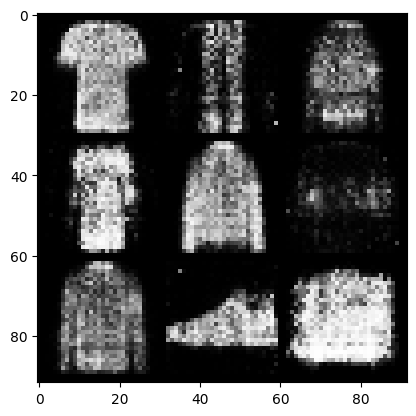

Starting epoch 16...
g_loss: 1.5930557250976562, d_loss: 0.9154297113418579


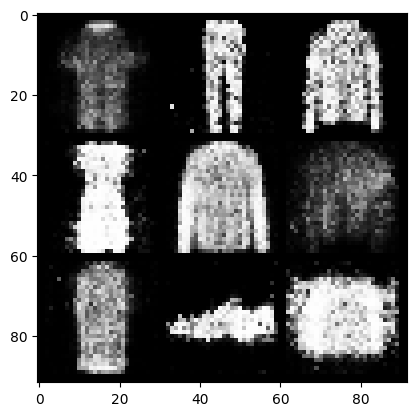

Starting epoch 17...
g_loss: 1.3584849834442139, d_loss: 1.08048415184021


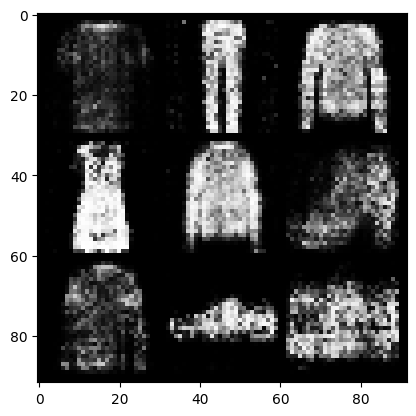

Starting epoch 18...
g_loss: 1.6536462306976318, d_loss: 0.804399847984314


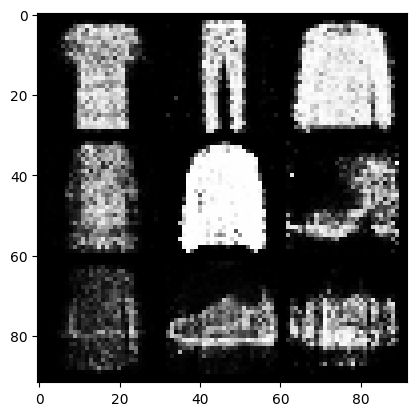

Starting epoch 19...
g_loss: 1.371823787689209, d_loss: 1.0233036279678345


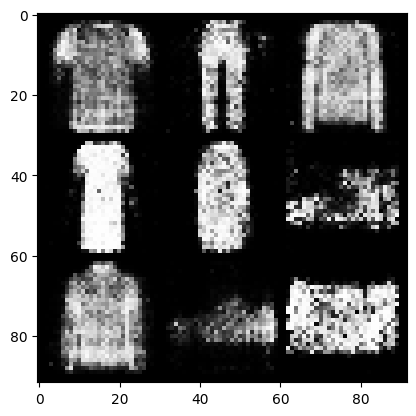

Starting epoch 20...
g_loss: 1.2253113985061646, d_loss: 1.1992597579956055


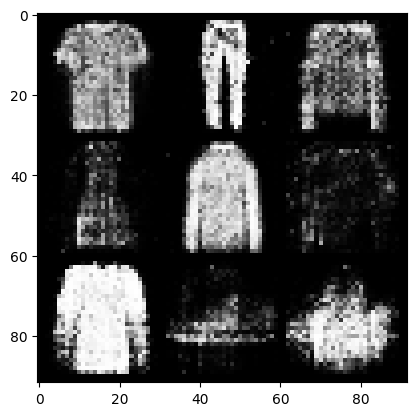

Starting epoch 21...
g_loss: 1.0552539825439453, d_loss: 1.090737223625183


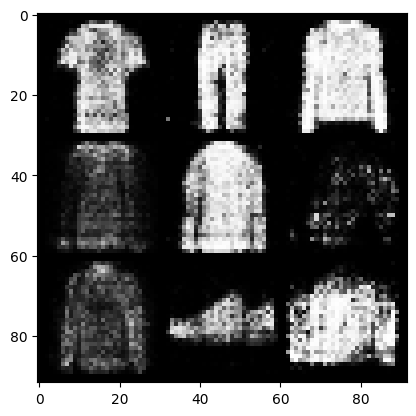

Starting epoch 22...
g_loss: 1.3145759105682373, d_loss: 0.9422584176063538


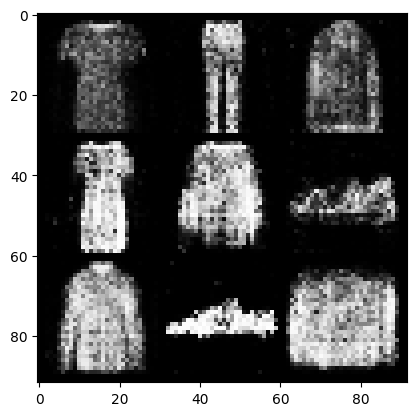

Starting epoch 23...
g_loss: 1.4843355417251587, d_loss: 0.9075837135314941


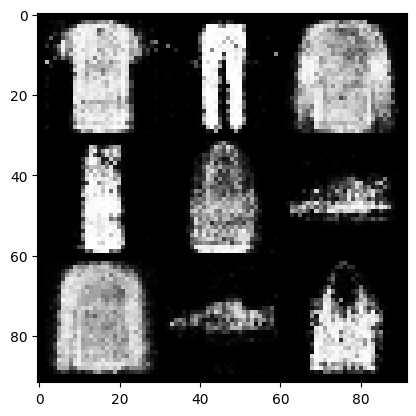

Starting epoch 24...
g_loss: 1.0454683303833008, d_loss: 1.1262245178222656


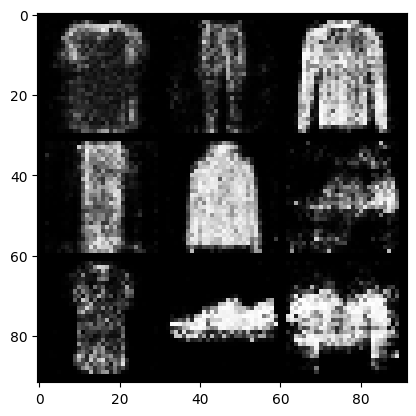

Starting epoch 25...
g_loss: 1.1362392902374268, d_loss: 1.0452585220336914


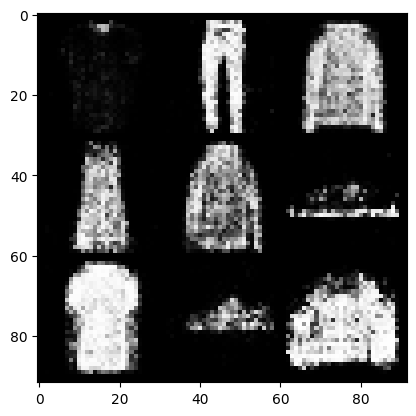

Starting epoch 26...
g_loss: 1.2622054815292358, d_loss: 1.0964329242706299


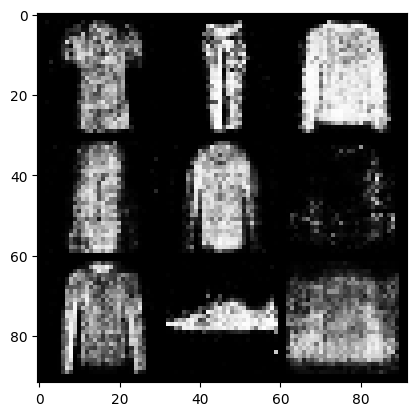

Starting epoch 27...
g_loss: 1.0532546043395996, d_loss: 1.3266832828521729


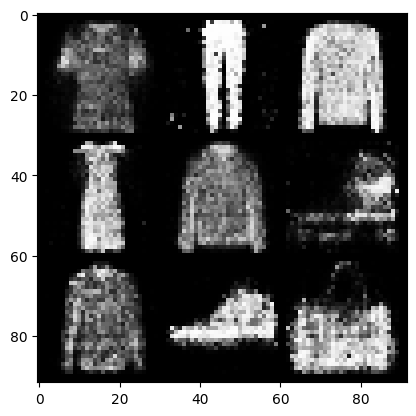

Starting epoch 28...
g_loss: 1.0643274784088135, d_loss: 1.0187801122665405


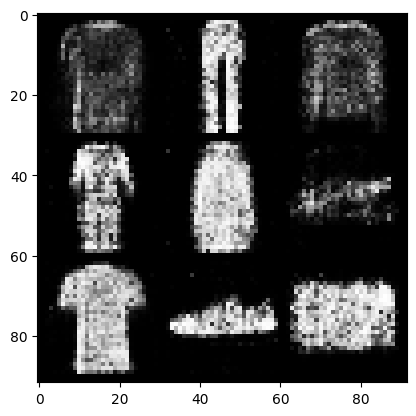

Starting epoch 29...
g_loss: 1.115786075592041, d_loss: 1.0084035396575928


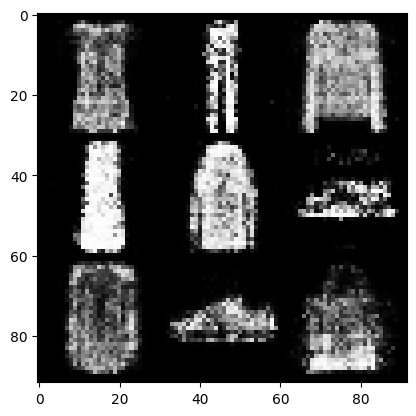

In [60]:
num_epochs = 30
n_critic = 5
display_step = 300
for epoch in range(num_epochs):
    print('Starting epoch {}...'.format(epoch))
    for i, (images, labels) in enumerate(data_loader):
        real_images = Variable(images).cuda()
        labels = Variable(labels).cuda()
        generator.train()
        batch_size = real_images.size(0)
        d_loss = discriminator_train_step(len(real_images), discriminator,
                                          generator, d_optimizer, criterion,
                                          real_images, labels)
        

        g_loss = generator_train_step(batch_size, discriminator, generator, g_optimizer, criterion)

    generator.eval()
    print('g_loss: {}, d_loss: {}'.format(g_loss, d_loss))
    z = Variable(torch.randn(9, 100)).cuda()
    labels = Variable(torch.LongTensor(np.arange(9))).cuda()
    sample_images = generator(z, labels).unsqueeze(1).data.cpu()
    grid = make_grid(sample_images, nrow=3, normalize=True).permute(1,2,0).numpy()
    plt.imshow(grid)
    plt.show()


# Style GAN

In [1]:
# Clone the official NVIDIA repo
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git

Cloning into 'stylegan2-ada-pytorch'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 131 (delta 0), reused 0 (delta 0), pack-reused 129 (from 2)
Receiving objects: 100% (131/131), 1.13 MiB | 342.00 KiB/s, done.
Resolving deltas: 100% (57/57), done.


In [2]:
%cd stylegan2-ada-pytorch

/home/monsley/Downloads/online/GenAI/100802025/stylegan2-ada-pytorch


/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
# Download a pretrained model (FFHQ = high-quality faces)
!wget https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl

--2025-08-09 19:48:19--  https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl
Resolving nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)... 52.84.205.17, 52.84.205.115, 52.84.205.22, ...
Connecting to nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)|52.84.205.17|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381624121 (364M) [binary/octet-stream]
Saving to: ‘ffhq.pkl’

ffhq.pkl            100%[===================>] 363.94M  26.0MB/s    in 15s     

2025-08-09 19:48:35 (24.2 MB/s) - ‘ffhq.pkl’ saved [381624121/381624121]



In [4]:
# Generating images from the pretrained model
!python generate.py --outdir=out --trunc=1 --seeds=0-9 --network=ffhq.pkl


Loading networks from "ffhq.pkl"...
Generating image for seed 0 (0/10) ...
Setting up PyTorch plugin "bias_act_plugin"... /home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/torch/utils/cpp_extension.py:2356: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(
Done.
Setting up PyTorch plugin "upfirdn2d_plugin"... /home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/torch/utils/cpp_extension.py:2356: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(
Done.
Generating image for seed 1 (1/10) ...
Generating image for seed 2 (2/10) ...
Generating image for seed 3 (3/10) ...
Generating image for seed 4 (4/10) ...
Generating image for seed 5 (5/10) ...
Generating image for seed 6 (6/10) ...
Genera

In [ ]:
# ffhq.pkl → Pretrained on Flickr-Faces-HQ dataset, ultra-realistic 1024×1024 faces.
#         --trunc=1 → Controls variety vs. quality (lower = higher quality, less diversity).
#         --seeds=0-9 → Generates 10 different images.
# Hey, please note that will be saved in out/.

In [ ]:
# source:
https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
https://github.com/NVlabs/stylegan2-ada-pytorch
https://github.com/NVlabs/ffhq-dataset

# Thanks everyone.....